# Spectral analysis of phase-contrast movies

This program loads images processed from Fiji and calculates average spectra.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2026 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 16/03/2026
    
    Multiphase Flow Laboratory
    Monash University, Australia


In [1]:
# core functions for image handling and plotting
#from pySciCam.pySciCam import ImageSequence # https://github.com/djorlando24/pySciCam

from PIL import Image
import numpy as np
from tqdm.notebook import tqdm

In [2]:
import matplotlib.pyplot as plt
%matplotlib widget

In [3]:
def read_multipage_tiff(path):
    """
    Reads a multipage-tiff file and returns a list of frames as NumPy arrays.
    """
    img = Image.open(path)
    images = []
    for i in range(img.n_frames):
        img.seek(i)
        # Convert the current frame to a NumPy array
        frame_array = np.array(img)
        images.append(frame_array)
    
    # The file handle is automatically closed by the context manager 
    # if you use 'with Image.open(...) as img:'
    # However, for multi-frame images, the file is left open until close() is called or the program ends.
    # Using 'with' helps ensure it's closed properly.
    return images

In [4]:
# Usage
file_path = '/Users/dduke/Desktop/8bitBkDiv_NozzleA_10bar_1bar_45deb_y-13.3.tif'
frames_list = read_multipage_tiff(file_path)

print(f"Total frames read: {len(frames_list)}")
print(f"Shape of the first frame: {frames_list[0].shape}")

Total frames read: 5236
Shape of the first frame: (600, 400)


In [5]:
# Convert list into ndarray
frames_array=np.dstack(frames_list)
del frames_list

In [6]:
# Compute stats
averageImage = np.nanmean(frames_array,axis=-1)
stdImage = np.nanstd(frames_array,axis=-1)

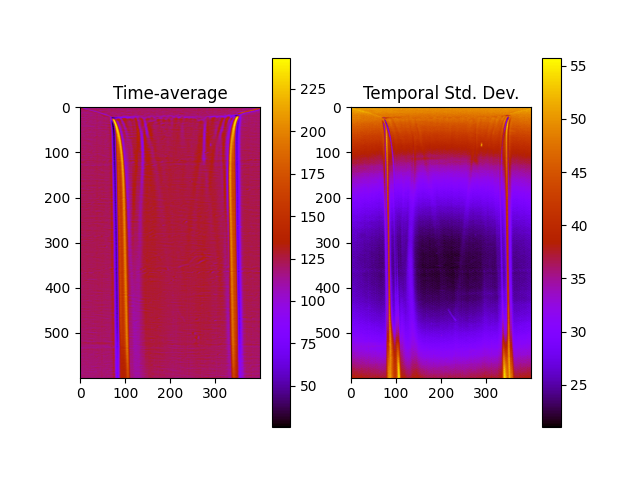

In [7]:
# Plot test figures
fig=plt.figure()
ax=fig.add_subplot(121)
h=ax.imshow(averageImage,cmap='gnuplot')
plt.title("Time-average")
plt.colorbar(h)
ax=fig.add_subplot(122)
h=ax.imshow(stdImage,cmap='gnuplot')
plt.title("Temporal Std. Dev.")
plt.colorbar(h);

## Spectral analysis

Pixelwise welch method and post average

In [8]:
from scipy.signal import welch
from joblib import Parallel, delayed

In [9]:
print(frames_array.shape)

(600, 400, 5236)


In [130]:
nperseg=1024 # output is half this
fs=2000. # fps

#welch_output = np.zeros((frames_array.shape[0],frames_array.shape[1], int(nperseg/2 + 1)))

# Computation of per-pixel spectra
def welch_fun(xx): #noverlap=int(nperseg * (3/4))
    return welch(xx, fs, nperseg=nperseg,\
                 detrend='linear', noverlap = None, return_onesided=True,\
                 scaling='density')
    
def welch_vector(x):
    welch_output = np.zeros((x.shape[0], int(nperseg/2 + 1)))
    for j in range(x.shape[0]):
        f, Pxx = welch_fun(x[j,:])
        welch_output[j,:] = Pxx
    return welch_output

print(frames_array.shape[0])

600


In [131]:
all_output = Parallel(n_jobs=-1, backend="threading", verbose=10)\
    (delayed(welch_vector)(frames_array[i,...]) for i in range(frames_array.shape[0]))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   21.0s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   21.6s
[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:   34.8s
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:   42.4s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:   49.5s
[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed:   56.5s
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 125 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 161 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 201 tasks      | elaps

## Spatially-average spectrum

In [132]:
# Get freq
fs=2000.
f, Pxx = welch_fun(frames_array[0,0,:])

# Convert output of above function into 3d ndarray
Pxx = np.dstack(all_output)
Pxx = np.rollaxis(Pxx,2,0)
print(Pxx.shape)

(600, 400, 513)


In [149]:
# Calculate strouhal number
p1=10e5
p2=1e5
d=0.5e-3
rhol=800

A = (np.pi/4.)*(d**2)
K = (p1-0)/(p1-p2)

mdot = 0.611 * np.sqrt(K) * A * np.sqrt(2*rhol*(p1-p2))
Ubar = mdot / (rhol*A)
print("Ubar = %f m/s" % Ubar)

###
Str = f*d/Ubar

Ubar = 30.550000 m/s


In [150]:
meanSpectrum=np.nanmean(Pxx,axis=(0,1))
stdSpectrum=np.nanstd(Pxx,axis=(0,1))

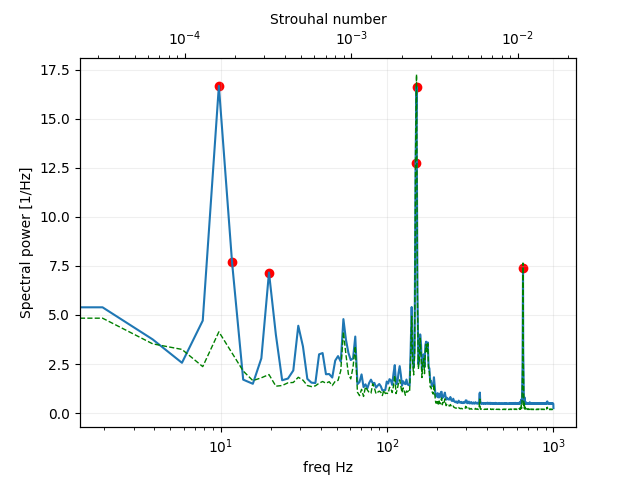

In [152]:
fig=plt.figure()
ax=fig.add_subplot(111)
plt.grid(alpha=.2)
ax.plot(f, meanSpectrum)
plt.xlabel("freq Hz");
plt.ylabel("Spectral power [1/Hz]");
ax2=ax.twiny()
ax2.plot(Str, stdSpectrum,ls='--',c='g',lw=1)
plt.xlabel("Strouhal number");

ax.set_xscale('log'); ax2.set_xscale('log')

indices = np.argpartition(-meanSpectrum, 6)[:6]
#delta=np.hstack((np.diff(indices),(1e6,)))
#indices=indices[delta>=5]
ax.scatter(f[indices],meanSpectrum[indices],c='r');

## Map frequency peaks

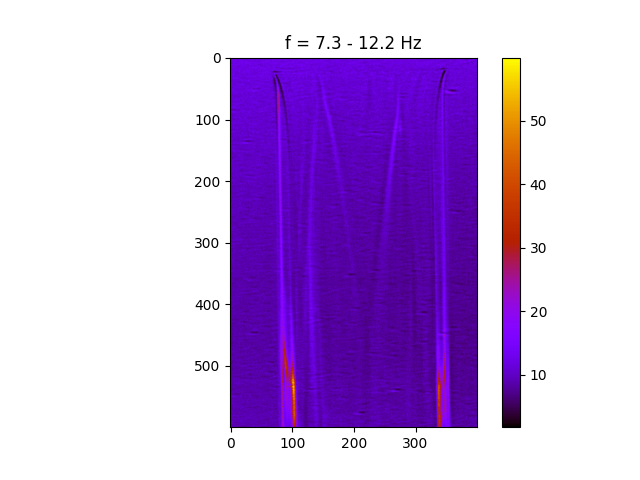

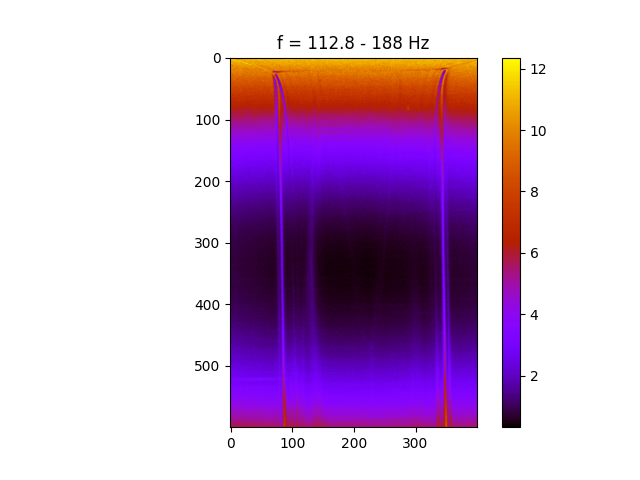

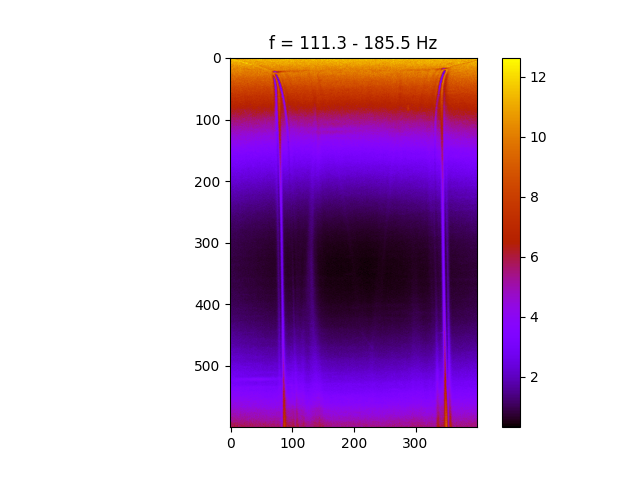

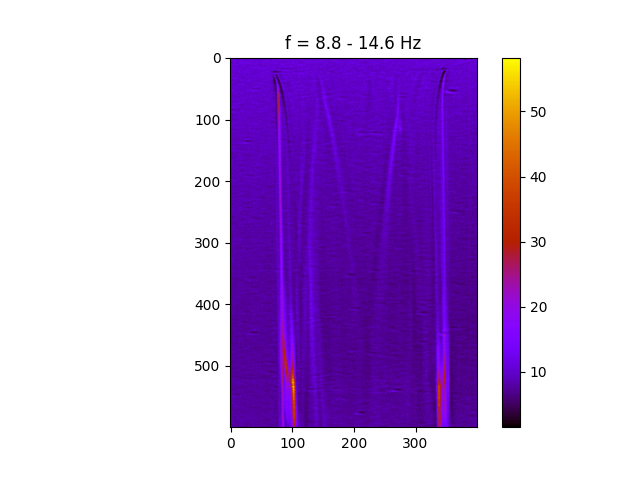

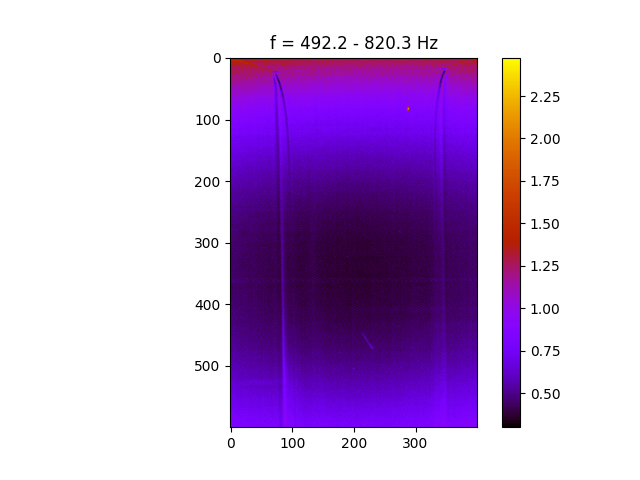

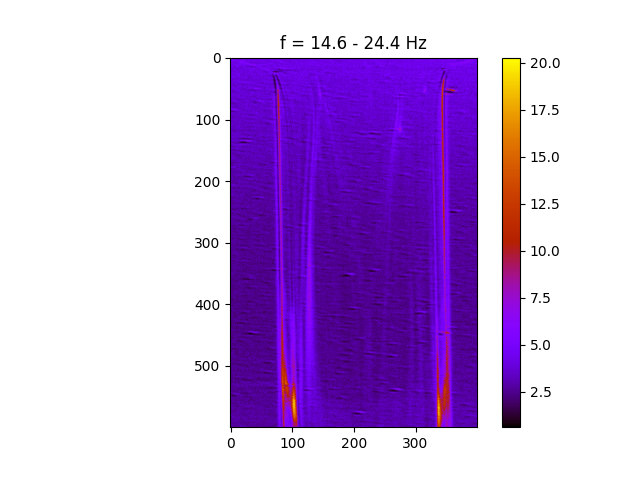

In [153]:
for fcent in f[indices]:
    fmin=np.round(fcent*0.75,1); fmax=np.round(fcent*1.25,1);
    if(fmin<0): fmin=0
    if(fmax>max(f)): fmax=max(f)
        
    fbin = np.where((f>=fmin) & (f<=fmax))[0]
    
    Pxx_bin = np.zeros((Pxx.shape[0],Pxx.shape[1]))
    for b in fbin:
        Pxx_bin += Pxx[...,b]
    Pxx_bin /= float(len(fbin))
    
    fig=plt.figure()
    h=plt.imshow(Pxx_bin,cmap='gnuplot')
    plt.title("f = %g - %g Hz" % (fmin,fmax))
    plt.colorbar(h);